# regression

In [10]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing(as_frame=True)

X = data.data
y = data.target

print(X.shape)
print(X.head())
print(y.head())

(20640, 8)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

rmse = mean_squared_error(
    y_test,
    pred,
)

r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.25602182673365537
R2: 0.8046244867176197


In [6]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

X_train_var = selector.fit_transform(X_train)

selected_features = X_train.columns[
    selector.get_support()
]

print(selected_features)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='str')


In [8]:
print(
    X_train.columns[
        selector.get_support()
    ].tolist()
)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


correlation

In [11]:
corr = X_train.corr()

corr

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
MedInc,1.000000,-0.121711,0.336013,-0.072550,0.004122,0.022061,-0.076571,-0.017040
HouseAge,-0.121711,1.000000,-0.160892,-0.087983,-0.292283,0.016245,0.005296,-0.101818
AveRooms,0.336013,-0.160892,1.000000,0.836163,-0.073733,-0.004922,0.110695,-0.029339
AveBedrms,-0.072550,-0.087983,0.836163,1.000000,-0.071267,-0.006035,0.073161,0.016647
Population,0.004122,-0.292283,-0.073733,-0.071267,1.000000,0.072330,-0.102499,0.094276
AveOccup,0.022061,0.016245,-0.004922,-0.006035,0.072330,1.000000,0.005837,-0.000598
Latitude,-0.076571,0.005296,0.110695,0.073161,-0.102499,0.005837,1.000000,-0.924485
Longitude,-0.017040,-0.101818,-0.029339,0.016647,0.094276,-0.000598,-0.924485,1.000000


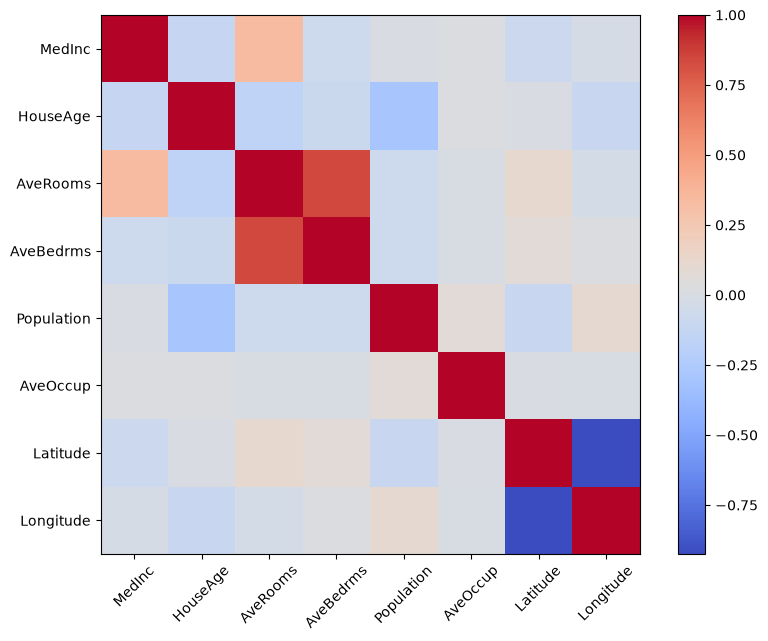

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.show()

In [13]:
import numpy as np
threshold = 0.90
corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > threshold)
]

print("Features to drop:")
print(to_drop)

Features to drop:
['Longitude']


In [14]:
target_corr = X_train.copy()

target_corr["Target"] = y_train

print(
    target_corr.corr()["Target"]
    .sort_values(ascending=False)
)

Target        1.000000
MedInc        0.690647
AveRooms      0.158485
HouseAge      0.103706
AveOccup     -0.022030
Population   -0.026032
Longitude    -0.046349
AveBedrms    -0.051351
Latitude     -0.142983
Name: Target, dtype: float64


Mutual Information

In [15]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(
    X_train,
    y_train,
    random_state=42
)

mi_scores = pd.Series(
    mi,
    index=X_train.columns
).sort_values(
    ascending=False
)

print(mi_scores)

Longitude     0.390324
MedInc        0.385566
Latitude      0.362238
AveRooms      0.101206
AveOccup      0.076144
HouseAge      0.035883
Population    0.026614
AveBedrms     0.025290
dtype: float64


In [17]:
top_features = mi_scores.head(5).index.tolist()

print(top_features)

['Longitude', 'MedInc', 'Latitude', 'AveRooms', 'AveOccup']


In [18]:
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

In [19]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train_selected,
    y_train
)

pred = model.predict(
    X_test_selected
)

rmse = mean_squared_error(
    y_test,
    pred
)

r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.2468095532475682
R2: 0.8116545617850645


SelectKBest + F Regression

In [20]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

selector = SelectKBest(
    score_func=f_regression,
    k=5
)

X_train_selected = selector.fit_transform(
    X_train,
    y_train
)


selected_features = X_train.columns[
    selector.get_support()
]

print(selected_features)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude'], dtype='str')


In [21]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

estimator = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rfe = RFE(
    estimator=estimator,
    n_features_to_select=5
)

rfe.fit(
    X_train,
    y_train
)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",RandomForestR...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",5
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
estimator_ estimator_: ``Estimator`` instanceThe fitted estimator used to select features.,RandomForestRegressor,RandomForestR...ndom_state=42)
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
n_features_ n_features_: intThe number of selected features.,int64,np.int64(5)
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,8
"ranking_ ranking_: ndarray of shape (n_features,)The feature ranking, such that ``ranking_[i]`` corresponds to theranking position of the i-th feature. Selected (i.e., estimatedbest) features are assigned rank 1.","ndarray[int64](8,)","[1,1,2,...,1,1,1]"


In [22]:
selected_features = X_train.columns[
    rfe.support_
]

print(selected_features)

Index(['MedInc', 'HouseAge', 'AveOccup', 'Latitude', 'Longitude'], dtype='str')


In [23]:
ranking = pd.Series(
    rfe.ranking_,
    index=X_train.columns
).sort_values()

print(ranking)

MedInc        1
HouseAge      1
Latitude      1
AveOccup      1
Longitude     1
AveRooms      2
Population    3
AveBedrms     4
dtype: int64


RFECV

In [24]:
from sklearn.feature_selection import RFECV

estimator = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rfecv = RFECV(
    estimator=estimator,
    step=1,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rfecv.fit(
    X_train,
    y_train
)

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,RandomForestR...ndom_state=42)
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",5
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",-1
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"cv_results_ cv_results_: dict of ndarraysAll arrays (values of the dictionary) are sorted in ascending orderby the number of features used (i.e., the first element of the arrayrepresents the models that used the least number of features, while thelast element represents the models that used all available features)... versionadded:: 1.0This dictionary contains the following keys:split(k)_test_score : ndarray of shape (n_subsets_of_features,) The cross-validation scores across (k)th fold.mean_test_score : ndarray of shape (n_subsets_of_features,) Mean of scores over the folds.std_test_score : ndarray of shape (n_subsets_of_features,) Standard deviation of scores over the folds.n_features : ndarray of shape (n_subsets_of_features,) Number of features used at each step. .. versionad

In [25]:
print(
    "Optimal number of features:",
    rfecv.n_features_
)

Optimal number of features: 6


In [26]:
selected_features = X_train.columns[
    rfecv.support_
]

print(selected_features)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'Latitude', 'Longitude'], dtype='str')


In [27]:
rfecv.support_

array([ True,  True,  True, False, False,  True,  True,  True])

lasso

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline

lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        Lasso(
            alpha=0.01
        )
    )
])

lasso_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

lasso = Lasso(
    alpha=0.01
)

lasso.fit(
    X_train_scaled,
    y_train
)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [30]:
coef = pd.Series(
    lasso.coef_,
    index=X_train.columns
)

print(coef.sort_values())

Latitude     -0.790113
Longitude    -0.755674
AveRooms     -0.162759
AveOccup     -0.030602
Population   -0.000000
HouseAge      0.127087
AveBedrms     0.206207
MedInc        0.800957
dtype: float64


In [31]:
selected_features = coef[
    coef != 0
].index.tolist()

print(selected_features)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup', 'Latitude', 'Longitude']


In [33]:
selected_features = coef[
    coef == 0
].index.tolist()

print(selected_features)

['Population']


Random Forest Feature Importance

In [34]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [35]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(
    ascending=False
)

print(importance)

MedInc        0.525926
AveOccup      0.138013
Latitude      0.088766
Longitude     0.088166
HouseAge      0.054378
AveRooms      0.044370
Population    0.030760
AveBedrms     0.029621
dtype: float64


In [ ]:
top_features = importance.head(5).index

print(top_features)

In [ ]:
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

Permutation Importance

In [36]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [37]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [38]:
perm_importance = pd.Series(
    result.importances_mean,
    index=X_test.columns
).sort_values(
    ascending=False
)

print(perm_importance)

MedInc        0.601851
Latitude      0.409265
Longitude     0.329497
AveOccup      0.217357
HouseAge      0.086325
AveRooms      0.033419
AveBedrms     0.012220
Population    0.010943
dtype: float64


مقایسه چند روش با Cross Validation

In [39]:
# Baseline
baseline = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
# MI + Random Forest
mi_pipeline = Pipeline([
    (
        "selection",
        SelectKBest(
            mutual_info_regression,
            k=5
        )
    ),
    (
        "model",
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    )
])
# RFE + Random Forest
rfe_pipeline = Pipeline([
    (
        "selection",
        RFE(
            estimator=RandomForestRegressor(
                n_estimators=50,
                random_state=42,
                n_jobs=-1
            ),
            n_features_to_select=5
        )
    ),
    (
        "model",
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [40]:
from sklearn.model_selection import cross_val_score

models = {
    "Baseline": baseline,
    "MI": mi_pipeline,
    "RFE": rfe_pipeline
}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    rmse = -scores

    print(
        name,
        "Mean RMSE:",
        rmse.mean(),
        "Std:",
        rmse.std()
    )

Baseline Mean RMSE: 0.5111276306108562 Std: 0.004630137757662688
MI Mean RMSE: 0.5057402116961842 Std: 0.005531261791953253
RFE Mean RMSE: 0.509900738083415 Std: 0.0053307984294579


In [ ]:
columns=["Method","Number of Features","CV RMSE"]
{"Baseline":[],
    "Correlation":[] ,
    "Mutual Information":[],
    "RFE" :[],
    "RFE":[],
    "RFECV" :[],
    "Lasso":[],
    "Random Forest Importance" :[],}
pd.Dataframe()

# classification

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

print(X.shape)
print(y.value_counts())
X.head()

(569, 30)
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
sum(y)/len(y)

0.6274165202108963

baseline

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, pred))
print("F1:", f1_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))

Accuracy: 0.956140350877193
F1: 0.9655172413793104
ROC-AUC: 0.9930555555555556


Variance Threshold

In [46]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

X_train_var = selector.fit_transform(X_train)
X_test_var = selector.transform(X_test)

selected_features = X_train.columns[selector.get_support()]

print("Selected features:")
print(selected_features)

print("Number of features:", len(selected_features))

Selected features:
Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst compactness', 'worst concavity'],
      dtype='str')
Number of features: 14


correlation

In [47]:
import numpy as np

corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Features to drop:")
print(to_drop)

Features to drop:
['mean perimeter', 'mean area', 'mean concave points', 'perimeter error', 'area error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst concave points']


ANOVA

In [48]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(
    score_func=f_classif,
    k=10
)

X_train_selected = selector.fit_transform(
    X_train,
    y_train
)

X_test_selected = selector.transform(X_test)

selected_features = X_train.columns[
    selector.get_support()
]

print(selected_features)

Index(['mean radius', 'mean perimeter', 'mean area', 'mean concavity',
       'mean concave points', 'worst radius', 'worst perimeter', 'worst area',
       'worst concavity', 'worst concave points'],
      dtype='str')


In [49]:
scores = pd.Series(
    selector.scores_,
    index=X_train.columns
).sort_values(ascending=False)

print(scores)

worst concave points       795.223341
worst perimeter            719.598823
mean concave points        703.364031
worst radius               687.430367
mean perimeter             565.485755
worst area                 541.713694
mean radius                523.613907
mean area                  469.516453
mean concavity             416.374874
worst concavity            365.747389
mean compactness           269.466042
worst compactness          257.926057
area error                 214.858763
radius error               212.499767
perimeter error            198.422440
worst texture              115.516608
worst symmetry             103.007806
worst smoothness           102.307653
concave points error        96.219300
mean texture                91.206254
mean smoothness             82.347538
mean symmetry               66.751304
worst fractal dimension     54.353019
compactness error           41.984658
concavity error             30.922841
smoothness error             2.263215
fractal dime

Chi Square

In [51]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

In [52]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


selector = SelectKBest(
    score_func=chi2,
    k=10
)

X_train_chi = selector.fit_transform(
    X_train_scaled,
    y_train
)

X_test_chi = selector.transform(
    X_test_scaled
)

selected_features = X_train.columns[
    selector.get_support()
]

print(selected_features)

Index(['mean radius', 'mean perimeter', 'mean area', 'mean concavity',
       'mean concave points', 'worst radius', 'worst perimeter', 'worst area',
       'worst concavity', 'worst concave points'],
      dtype='str')


In [53]:
chi_scores = pd.Series(
    selector.scores_,
    index=X_train.columns
).sort_values(ascending=False)

print(chi_scores)

mean concave points        43.014866
worst concave points       38.919172
mean concavity             38.169774
worst area                 34.045640
worst perimeter            30.528326
worst radius               29.960403
worst concavity            27.309722
mean area                  23.111138
mean perimeter             21.266644
mean radius                19.908251
worst compactness          17.992415
mean compactness           17.609934
area error                 15.135934
radius error               13.098711
perimeter error            12.285829
worst texture               6.992442
mean texture                5.235841
worst symmetry              5.153318
concave points error        5.106327
worst smoothness            4.723624
mean smoothness             4.572075
compactness error           4.235510
worst fractal dimension     3.739781
mean symmetry               3.110516
concavity error             2.358153
fractal dimension error     0.146457
smoothness error            0.140432
t

mutual info

In [54]:
from sklearn.feature_selection import mutual_info_classif


mi = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_scores = pd.Series(
    mi,
    index=X_train.columns
).sort_values(ascending=False)

print(mi_scores)

worst perimeter            0.471238
worst area                 0.461952
worst radius               0.458392
mean concave points        0.443749
worst concave points       0.442864
mean perimeter             0.411013
mean radius                0.364736
mean area                  0.357780
mean concavity             0.353144
area error                 0.337466
worst concavity            0.317258
mean compactness           0.247454
perimeter error            0.244903
worst compactness          0.235523
radius error               0.232290
worst texture              0.159857
concavity error            0.141872
concave points error       0.125679
mean texture               0.116786
mean smoothness            0.096462
worst symmetry             0.088189
worst smoothness           0.081353
mean symmetry              0.064020
compactness error          0.059310
worst fractal dimension    0.056122
texture error              0.037957
fractal dimension error    0.030016
symmetry error             0

In [55]:
top_features = mi_scores.head(10).index

print(top_features)

Index(['worst perimeter', 'worst area', 'worst radius', 'mean concave points',
       'worst concave points', 'mean perimeter', 'mean radius', 'mean area',
       'mean concavity', 'area error'],
      dtype='str')


RFE

In [56]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

estimator = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rfe = RFE(
    estimator=estimator,
    n_features_to_select=10
)

rfe.fit(X_train, y_train)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",RandomForestC...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",10
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only available when `estimator` is a classifier.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: ``Estimator`` instanceThe fitted estimator used to select features.,RandomForestClassifier,RandomForestC...ndom_state=42)
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_ n_features_: intThe number of selected features.,int64,np.int64(10)
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,30


In [57]:
selected_features = X_train.columns[rfe.support_]

print(selected_features)

Index(['mean perimeter', 'mean area', 'mean concavity', 'mean concave points',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst concavity', 'worst concave points'],
      dtype='str')


In [58]:
ranking = pd.Series(
    rfe.ranking_,
    index=X_train.columns
).sort_values()

print(ranking)

mean area                   1
mean perimeter              1
mean concavity              1
mean concave points         1
worst radius                1
worst texture               1
worst perimeter             1
worst area                  1
worst concave points        1
worst concavity             1
mean radius                 2
area error                  3
mean texture                4
worst smoothness            5
worst symmetry              6
worst compactness           7
perimeter error             8
radius error                9
worst fractal dimension    10
mean compactness           11
texture error              12
compactness error          13
fractal dimension error    14
mean symmetry              15
concave points error       16
symmetry error             17
concavity error            18
mean fractal dimension     19
mean smoothness            20
smoothness error           21
dtype: int64


RFECV

In [59]:
from sklearn.feature_selection import RFECV

estimator = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rfecv = RFECV(
    estimator=estimator,
    step=1,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rfecv.fit(X_train, y_train)

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,RandomForestC...ndom_state=42)
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",5
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.",'f1'
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",-1
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only available when `estimator` is a classifier.","ndarray[int64](2,)","[0,1]"
"cv_results_ cv_results_: dict of ndarraysAll arrays (values of the dictionary) are sorted in ascending orderby the number of features used (i.e., the first element of the arrayrepresents the models that used the least number of features, while thelast element represents the models that used all available features)... versionadded:: 1.0This dictionary contains the following keys:split(k)_test_score : ndarray of shape (n_subsets_of_features,) The cross-validation scores across (k)th fold.mean_test_score : ndarray of shape (n_subsets_of_features,) Mean of scores over the folds.std_test_score : ndarray of shape (n_subsets_of_features,) Standard deviation of scor

In [60]:
print(rfecv.n_features_)

12


In [61]:
selected_features = X_train.columns[
    rfecv.support_
]

print(selected_features)

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean concave points', 'area error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst concavity',
       'worst concave points'],
      dtype='str')


Lasso

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=0.1,
        random_state=42
    ))
])

model.fit(X_train, y_train)


coefficients = model.named_steps["classifier"].coef_[0]

coef = pd.Series(
    coefficients,
    index=X_train.columns
)

print(coef.sort_values())

worst radius              -2.122532
worst concave points      -0.943057
worst texture             -0.575617
mean concave points       -0.500713
radius error              -0.431542
worst smoothness          -0.206336
worst symmetry            -0.173980
mean texture              -0.049188
mean concavity             0.000000
mean symmetry              0.000000
mean fractal dimension     0.000000
mean perimeter             0.000000
mean area                  0.000000
mean smoothness            0.000000
mean compactness           0.000000
mean radius                0.000000
compactness error          0.000000
smoothness error           0.000000
area error                 0.000000
perimeter error            0.000000
texture error              0.000000
fractal dimension error    0.000000
concavity error            0.000000
concave points error       0.000000
worst area                 0.000000
worst perimeter            0.000000
symmetry error             0.000000
worst compactness          0

d:\codes\mlflow\NetworkSequrity\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\codes\mlflow\NetworkSequrity\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [64]:
selected_features = coef[coef != 0].index

print("Selected:")
print(selected_features)

Selected:
Index(['mean texture', 'mean concave points', 'radius error', 'worst radius',
       'worst texture', 'worst smoothness', 'worst concave points',
       'worst symmetry'],
      dtype='str')


In [65]:
selected_features = coef[coef == 0].index

print("Selected:")
print(selected_features)

Selected:
Index(['mean radius', 'mean perimeter', 'mean area', 'mean smoothness',
       'mean compactness', 'mean concavity', 'mean symmetry',
       'mean fractal dimension', 'texture error', 'perimeter error',
       'area error', 'smoothness error', 'compactness error',
       'concavity error', 'concave points error', 'symmetry error',
       'fractal dimension error', 'worst perimeter', 'worst area',
       'worst compactness', 'worst concavity', 'worst fractal dimension'],
      dtype='str')


Feature Importance در Random Forest

In [66]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

worst perimeter            0.133100
worst area                 0.128052
worst concave points       0.108107
mean concave points        0.094414
worst radius               0.090639
mean radius                0.058662
mean perimeter             0.055242
mean area                  0.049938
mean concavity             0.046207
worst concavity            0.035357
area error                 0.034368
mean compactness           0.018094
worst texture              0.017869
worst compactness          0.014481
mean texture               0.014317
worst smoothness           0.014026
radius error               0.013454
worst symmetry             0.009570
perimeter error            0.008138
concavity error            0.007136
worst fractal dimension    0.006387
mean smoothness            0.006168
texture error              0.005441
mean symmetry              0.005004
compactness error          0.004630
symmetry error             0.004611
mean fractal dimension     0.004465
fractal dimension error    0

In [67]:
top_features = importance.head(10).index

print(top_features)

Index(['worst perimeter', 'worst area', 'worst concave points',
       'mean concave points', 'worst radius', 'mean radius', 'mean perimeter',
       'mean area', 'mean concavity', 'worst concavity'],
      dtype='str')


Permutation Importance

In [68]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)


perm_importance = pd.Series(
    result.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

print(perm_importance)

mean area                  0.007184
compactness error          0.007184
worst perimeter            0.007080
worst area                 0.006778
mean concave points        0.006496
worst radius               0.005757
mean radius                0.005747
worst texture              0.005747
concave points error       0.005029
worst concave points       0.004369
worst fractal dimension    0.004310
mean smoothness            0.004310
radius error               0.003592
mean perimeter             0.003592
worst smoothness           0.002874
symmetry error             0.002874
mean fractal dimension     0.002874
smoothness error           0.001437
concavity error            0.001437
worst symmetry             0.000718
mean concavity             0.000718
area error                 0.000718
perimeter error            0.000000
texture error              0.000000
mean symmetry              0.000000
mean compactness           0.000000
mean texture               0.000000
fractal dimension error    0

In [69]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import pandas as pd

data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

result = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance = pd.DataFrame({
    "feature": X_test.columns,
    "mean": result.importances_mean,
    "std": result.importances_std
})

importance = importance.sort_values(
    "mean",
    ascending=False
)

print(importance)

                    feature      mean       std
3                 mean area  0.007184  0.000000
15        compactness error  0.007184  0.000000
22          worst perimeter  0.007080  0.006282
23               worst area  0.006778  0.006788
7       mean concave points  0.006496  0.006007
20             worst radius  0.005757  0.004330
0               mean radius  0.005747  0.002874
21            worst texture  0.005747  0.002874
17     concave points error  0.005029  0.003292
27     worst concave points  0.004369  0.003571
29  worst fractal dimension  0.004310  0.003519
4           mean smoothness  0.004310  0.003519
10             radius error  0.003592  0.003592
2            mean perimeter  0.003592  0.003592
24         worst smoothness  0.002874  0.003519
18           symmetry error  0.002874  0.003519
9    mean fractal dimension  0.002874  0.003519
14         smoothness error  0.001437  0.002874
16          concavity error  0.001437  0.002874
28           worst symmetry  0.000718  0

Boruta

reg

In [12]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

boruta = BorutaPy(
    estimator=rf,
    n_estimators='auto',
    verbose=2,
    random_state=42
)

boruta.fit(X.values, y.values)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	8
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	8
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	8
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	8
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	8
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	8
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	8
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	8
Tentative: 	0
Rejected: 	0


BorutaPy finished running.

Iteration: 	9 / 100
Confirmed: 	8
Tentative: 	0
Rejected: 	0


,estimator,RandomForestR...0x252C8EE9D40)
,n_estimators,'auto'
,random_state,RandomState(M... 0x252C8EE9D40
,verbose,2
,perc,100
,alpha,0.05
,two_step,True
,max_iter,100
,early_stopping,False
,n_iter_no_change,20
Name,Type,Value


In [13]:
selected_features = X.columns[boruta.support_]

print(selected_features)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='str')


In [14]:
tentative_features = X.columns[boruta.support_weak_]

print(tentative_features)

Index([], dtype='str')


In [2]:
!pip install -i https://mirror-pypi.runflare.com/simple boruta

Looking in indexes: https://mirror-pypi.runflare.com/simple
     - 0 bytes ? 0:00:00
     - 8.8 kB ? 0:00:00
   - 0 bytes ? 0:00:00
   | 57.9 kB 534.9 kB/s 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

boruta = BorutaPy(
    estimator=rf,
    n_estimators='auto',
    verbose=2,
    random_state=42
)

boruta.fit(X.values, y.values)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	30
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	30
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	30
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	30
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	30
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	30
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	30
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	20
Tentative: 	10
Rejected: 	0
Iteration: 	9 / 100
Confirmed: 	20
Tentative: 	10
Rejected: 	0
Iteration: 	10 / 100
Confirmed: 	20
Tentative: 	10
Rejected: 	0
Iteration: 	11 / 100
Confirmed: 	20
Tentative: 	10
Rejected: 	0
Iteration: 	12 / 100
Confirmed: 	20
Tentative: 	10
Rejected: 	0
Iteration: 	13 / 100
Confirmed: 	20
Tentative: 	10
Rejected: 	0
Iteration: 	14 / 100
Confirmed: 	20
Tentative: 	10
Rejected: 	0
Iteration: 	15 / 100
Confirmed: 	20
Tentative: 	10
Rejected: 	0
Iteration: 	16 / 100
Confirmed: 	21
Tentative: 	9
Reject

,estimator,RandomForestC...0x252C6C92640)
,n_estimators,'auto'
,random_state,RandomState(M... 0x252C6C92640
,verbose,2
,perc,100
,alpha,0.05
,two_step,True
,max_iter,100
,early_stopping,False
,n_iter_no_change,20
Name,Type,Value


In [ ]:
boruta.

In [4]:
selected_features = X.columns[boruta.support_]

print(selected_features)

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'radius error', 'perimeter error', 'area error',
       'concavity error', 'concave points error', 'worst radius',
       'worst texture', 'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'],
      dtype='str')


In [5]:
tentative_features = X.columns[boruta.support_weak_]

print(tentative_features)

Index(['compactness error'], dtype='str')
